# Summary

## Dataset
- Approximately 37,000 tweets
- Split into **train**, **test**, and **validation** sets

---

## Preprocessing Pipeline *(completed by @pavan)*
Steps applied to raw tweets:
1. Convert to lowercase  
2. Remove mentions (`@usernames`) and URLs  
3. Replace emojis with text descriptions (using the `emoji` library)  
4. Replace slang words with standard forms  
5. Correct spelling errors using `pyspellchecker`  
6. Handle negations by tagging negated words with a `NOT_` prefix (using SpaCy)  
7. Remove punctuation and extra spaces  

- Final cleaned text stored in: **`Final_Cleaned_Tweet`**

---

## Preprocessing for Deep Bidirectional LSTM
1. Tokenize tweets by splitting on whitespace  
2. Build a vocabulary mapping each unique token to an integer ID  
3. Add special tokens:
   - `<pad>` for padding  
   - `<unk>` for unknown words  
4. Encode tweets into sequences of integer token IDs

---

## Label Encoding
- Original sentiment labels:
  - `'Mild_Neg'`, `'Mild_Pos'`, `'Neutral'`, `'Strong_Neg'`, `'Strong_Pos'`  
- Used `sklearn.preprocessing.LabelEncoder` to convert them into integer class indices  
- These integer labels are used as targets during model training

---

## Dataset & DataLoader (PyTorch)
- Created custom `Dataset` classes to return:
  - **Input tensor**: padded token sequences (fixed max length)  
  - **Target tensor**: corresponding sentiment class index  
- Used `DataLoader` for batching and shuffling during training and evaluation

---

## Deep Bidirectional LSTM Model
- Model outputs: raw logits for each sentiment class  
- `CrossEntropyLoss` internally applies **Softmax activation** to compute class probabilities

---

## Model Training
- **Loss Function**: `CrossEntropyLoss`  
- **Optimizer**: `Adam`  

Per epoch:
- Train on mini-batches of training data  
- Evaluate on validation data  
- Output:
  - Training loss  
  - Training accuracy  
  - Validation accuracy

---

## Model Evaluation
After training, the model was evaluated on the **test set**.

**Collected:**
- `all_preds`: predicted class labels  
- `all_probs`: predicted probabilities  
- `all_labels`: true labels  

**Computed and Plotted:**
- Confusion Matrix  
- F1 Score (per class)  
- Accuracy  
- AUC Curve (One-vs-Rest)

---

## Additional Implementation Notes
- Ensured all tensors (inputs and labels) are placed on the same device (CPU or GPU)  
- Converted labels to `long` dtype before passing to loss functions to avoid runtime errors 

---

## Scope for Tuning
- Address class imbalance in the dataset  
- Tune hyperparameters:
  - Learning rate  
  - Hidden size  
  - Number of LSTM layers  
  - Batch size  
  - Number of epochs  
- Perform deeper error analysis using confusion matrix insights ch size  
  - Number of epochs  
- Perform deeper error analysis using confusion matrix insights
curacy  
- AUC (Area Under Curve) for each class using One-vs-Rest ROC curves


In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import confusion_matrix, classification_report, f1_score, roc_auc_score, roc_curve, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import torch.nn.functional as F

In [2]:
X_train = pd.read_csv('X_train.csv')
X_test = pd.read_csv('X_test.csv')
X_val = pd.read_csv('X_val.csv')
y_train = pd.read_csv('y_train.csv')
y_test = pd.read_csv('y_test.csv')
y_val = pd.read_csv('y_val.csv')

In [3]:
X_train.sample(3)

,Tweet,Cleaned_Tweet,Final_Cleaned_Tweet
12298,Evolved strategy for #FreedomConvoy\n\nWithdra...,evolved strategy for freedomconvoy withdraw as...,evolve strategy freedomconvoy withdraw much mo...
19309,@RickRMehta @jenrichard @AcadiaFaculty This af...,this afternoon s department meeting was about ...,afternoon department meeting bad freedom convo...
25600,Is the Freedom Trucker Convoy going to do Mexi...,is the freedom trucker convoy going to do mexi...,freedom trucker convoy go mexico


In [4]:
y_test.sample(3)

,Sentiment
4591,Neutral
5738,Neutral
747,Neutral


In [5]:
print(f"X train shape:",X_train.shape)
print(f"X test shape:",X_test.shape)
print(f"X val shape:",X_val.shape)
print(f"y train shape:",y_train.shape)
print(f"y test shape:",y_test.shape)
print(f"y val shape:",y_val.shape)

X train shape: (26905, 3)
X test shape: (7500, 3)
X val shape: (4000, 3)
y train shape: (26905, 1)
y test shape: (7500, 1)
y val shape: (4000, 1)


In [6]:
print(X_train['Final_Cleaned_Tweet'].isnull().sum())

9


In [7]:
print(X_val['Final_Cleaned_Tweet'].isnull().sum())
print(X_test['Final_Cleaned_Tweet'].isnull().sum())

2
4


### Combine X_train and y_train into one DataFrame
(ensuring index alignment)

In [8]:
train_df = X_train.reset_index(drop=True).copy()
y_train_aligned = y_train.reset_index(drop=True)

train_df['Sentiment'] = y_train_aligned['Sentiment']


In [9]:
print(train_df.shape)
print(train_df['Sentiment'].value_counts())

(26905, 4)
Sentiment
Mild_Neg      5381
Mild_Pos      5381
Neutral       5381
Strong_Neg    5381
Strong_Pos    5381
Name: count, dtype: int64


In [10]:
train_df.sample(3)

,Tweet,Cleaned_Tweet,Final_Cleaned_Tweet,Sentiment
6645,@islander_pe @Dantewpark @CBCNews What is a fr...,pe what is a freedom pancake the freedom convo...,pe freedom pancake freedom convoy stupid,Mild_Pos
26219,FIRST READING: Trudeau cabinet casually discus...,first reading trudeau cabinet casually discuss...,first read trudeau cabinet casually discuss cr...,Strong_Pos
21217,@acoyne Oh please. We were invaded. @CPC_HQ si...,oh please we were invaded he sided w the occup...,oh please invade side w occupy force child eld...,Strong_Neg


In [11]:
print(train_df['Final_Cleaned_Tweet'].isnull().sum())

9


In [12]:
train_df = train_df.dropna(subset=['Final_Cleaned_Tweet'])
X_train_clean = train_df[['Tweet', 'Cleaned_Tweet', 'Final_Cleaned_Tweet']]
y_train_clean = train_df[['Sentiment']]

In [13]:
print(X_train_clean['Final_Cleaned_Tweet'].isnull().sum())

0


# Removing null values in test and val 

In [14]:
test_df = X_test.reset_index(drop=True).copy()
y_test_aligned = y_test.reset_index(drop=True)
test_df['Sentiment'] = y_test_aligned['Sentiment']
test_df = test_df.dropna(subset=['Final_Cleaned_Tweet'])
X_test_clean = test_df[['Tweet', 'Cleaned_Tweet', 'Final_Cleaned_Tweet']]
y_test_clean = test_df[['Sentiment']]


In [15]:
print(X_test_clean.shape[0], y_test_clean.shape[0])    # should match


7496 7496


In [16]:
print(X_test_clean['Final_Cleaned_Tweet'].isnull().sum())

0


In [17]:
val_df = X_val.reset_index(drop=True).copy()
y_val_aligned = y_val.reset_index(drop=True)
val_df['Sentiment'] = y_val_aligned['Sentiment']
val_df = val_df.dropna(subset=['Final_Cleaned_Tweet'])
X_val_clean = val_df[['Tweet', 'Cleaned_Tweet', 'Final_Cleaned_Tweet']]
y_val_clean = val_df[['Sentiment']]

In [18]:
print(X_val_clean.shape[0], y_val_clean.shape[0])

3998 3998


In [19]:
print(X_val_clean['Final_Cleaned_Tweet'].isnull().sum())

0


# Creating copies as backup to check after preprocessing

In [20]:
X_train_backup2 = X_train_clean.copy()
y_train_backup2 = y_train_clean.copy()

X_test_backup2 = X_test_clean.copy()
y_test_backup2 = y_test_clean.copy()

X_val_backup2 = X_val_clean.copy()
y_val_backup2 = y_val_clean.copy()

- Tokenized tweets
- Built a vocabulary
- Created an encode() function for turning text into sequences of integers

In [21]:
from collections import Counter
from itertools import chain

# Tokenize all tweets
tokenized_texts = [
    str(text).strip().split()
    for text in X_train_clean['Final_Cleaned_Tweet'].fillna('')
]

# Build vocab
counter = Counter(chain.from_iterable(tokenized_texts))
specials = ['<pad>', '<unk>']
vocab_dict = {token: idx for idx, token in enumerate(specials + list(counter.keys()))}
vocab_dict['<unk>'] = vocab_dict.get('<unk>', 1)

# Encoder function
def encode(text):
    return [vocab_dict.get(token, vocab_dict['<unk>']) for token in text.split()]



## Encode All tweets

In [22]:
X_train_encoded = [encode(text) for text in X_train_clean['Final_Cleaned_Tweet']]
X_val_encoded = [encode(text) for text in X_val_clean['Final_Cleaned_Tweet'].fillna('')]
X_test_encoded = [encode(text) for text in X_test_clean['Final_Cleaned_Tweet'].fillna('')]

## Pad Sequences
- Deep learning models require uniform-length sequences. So, pad or truncate them

In [23]:
from torch.nn.utils.rnn import pad_sequence
import torch

In [24]:
MAX_LEN = 50  # Adjust as needed based on tweet length distribution

def pad_sequences(sequences, max_len=MAX_LEN):
    return torch.stack([
        torch.tensor(seq[:max_len] + [vocab_dict['<pad>']] * (max_len - len(seq)))
        for seq in sequences
    ])

In [25]:
X_train_tensor = pad_sequences(X_train_encoded)
X_val_tensor = pad_sequences(X_val_encoded)
X_test_tensor = pad_sequences(X_test_encoded)


***Label Encoding***
Convert y_train_clean['Sentiment'] -> Strong_Pos, Neutral, etc.

In [26]:
label_encoder = LabelEncoder()
label_encoder.fit(y_train_clean['Sentiment'])

y_train_tensor = torch.tensor(label_encoder.transform(y_train_clean['Sentiment']))
y_val_tensor = torch.tensor(label_encoder.transform(y_val_clean['Sentiment']))
y_test_tensor = torch.tensor(label_encoder.transform(y_test_clean['Sentiment']))

In [27]:
print(X_train_tensor.shape[0], y_train_tensor.shape[0])  # should match
print(X_val_tensor.shape[0], y_val_tensor.shape[0])      # should match
print(X_test_tensor.shape[0], y_test_tensor.shape[0])    # should match

26896 26896
3998 3998
7496 7496


In [28]:
print("Classes in order:", label_encoder.classes_)
print("Train labels encoded as:", y_train_tensor.unique().tolist())
print("Val labels encoded as:", y_val_tensor.unique().tolist())
print("Test labels encoded as:", y_test_tensor.unique().tolist())


Classes in order: ['Mild_Neg' 'Mild_Pos' 'Neutral' 'Strong_Neg' 'Strong_Pos']
Train labels encoded as: [0, 1, 2, 3, 4]
Val labels encoded as: [0, 1, 2, 3, 4]
Test labels encoded as: [0, 1, 2, 3, 4]


In [29]:
print("y_train_tensor dtype:", y_train_tensor.dtype)  # should be torch.int64 or torch.long

y_train_tensor dtype: torch.int32


In [30]:
y_train_tensor = y_train_tensor.long()
y_val_tensor = y_val_tensor.long()

In [31]:
print("y_train_tensor dtype:", y_train_tensor.dtype) 

y_train_tensor dtype: torch.int64


- Save the label classes to decode predictions later

In [32]:
label_classes = label_encoder.classes_

In [33]:
from torch.utils.data import TensorDataset, DataLoader

In [34]:
BATCH_SIZE = 64

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [35]:
print("Sample label in dataset:", train_dataset[0][1])

Sample label in dataset: tensor(0)


In [36]:

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

# Model Building - Deep Bidirectional LSTM Model (with Embedding Layer)

In [37]:
class DeepBiLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, pad_idx):
        super(DeepBiLSTM, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=2, 
                            bidirectional=True, batch_first=True, dropout=0.3)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)  # bi-directional = 2x hidden
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = self.embedding(x)
        x, _ = self.lstm(x)
        x = self.dropout(x)
        x = x[:, -1, :]  # last time step
        return self.fc(x)


In [38]:
# Hyperparameters
embed_dim = 100
hidden_dim = 128
num_classes = len(np.unique(y_train_tensor))
batch_size = 64
num_epochs = 10
pad_idx = vocab_dict['<pad>']

# Initialize model
model = DeepBiLSTM(vocab_size=len(vocab_dict), 
                   embed_dim=embed_dim, 
                   hidden_dim=hidden_dim,
                   num_classes=num_classes,
                   pad_idx=pad_idx)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Dataloaders
train_data = TensorDataset(X_train_tensor, y_train_tensor)
val_data = TensorDataset(X_val_tensor, y_val_tensor)

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size)


In [39]:
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs):
    best_val_acc = 0.0

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        total_correct = 0
        total_samples = 0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.long().to(device)

            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch.to(torch.long))
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_correct += (predicted == y_batch).sum().item()
            total_samples += y_batch.size(0)

        train_acc = total_correct / total_samples

        # Validation
        model.eval()
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.long().to(device)

                outputs = model(X_batch)
                _, predicted = torch.max(outputs, 1)
                val_correct += (predicted == y_batch).sum().item()
                val_total += y_batch.size(0)

        val_acc = val_correct / val_total

        print(f"Epoch [{epoch+1}/{num_epochs}] | "
              f"Train Loss: {total_loss:.4f} | "
              f"Train Acc: {train_acc:.4f} | "
              f"Val Acc: {val_acc:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), "best_model.pt")


 ### y_batch in training loop must be LongTensor to avoid runtime errors.
 > CrossEntropyLoss expects target as class indices, not one-hot

In [40]:
print(f"Epochs: {num_epochs}")

Epochs: 10


In [41]:
print(f"Training batches: {len(train_loader)}")

Training batches: 421


In [42]:
print(X_train_tensor.shape, y_train_tensor.shape)

torch.Size([26896, 50]) torch.Size([26896])


In [43]:
train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs)

Epoch [1/10] | Train Loss: 677.9511 | Train Acc: 0.1958 | Val Acc: 0.0958
Epoch [2/10] | Train Loss: 677.8226 | Train Acc: 0.1966 | Val Acc: 0.0738
Epoch [3/10] | Train Loss: 677.6994 | Train Acc: 0.1992 | Val Acc: 0.0738
Epoch [4/10] | Train Loss: 677.6881 | Train Acc: 0.2030 | Val Acc: 0.1713
Epoch [5/10] | Train Loss: 677.6021 | Train Acc: 0.1979 | Val Acc: 0.1483
Epoch [6/10] | Train Loss: 677.5145 | Train Acc: 0.2010 | Val Acc: 0.0738
Epoch [7/10] | Train Loss: 677.4006 | Train Acc: 0.1983 | Val Acc: 0.1491
Epoch [8/10] | Train Loss: 677.4945 | Train Acc: 0.2000 | Val Acc: 0.1491
Epoch [9/10] | Train Loss: 669.2707 | Train Acc: 0.2384 | Val Acc: 0.4702
Epoch [10/10] | Train Loss: 613.9992 | Train Acc: 0.3620 | Val Acc: 0.5320


In [44]:
model.eval()
all_probs = []
all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        
        outputs = model(X_batch)  # raw logits from model, shape: (batch_size, num_classes)
        
        probs = torch.softmax(outputs, dim=1)  # convert logits to probabilities
        
        preds = torch.argmax(probs, dim=1)  # predicted class indices
        
        all_probs.append(probs.cpu())
        all_preds.append(preds.cpu())
        all_labels.append(y_batch.cpu())

# Concatenate all batches
all_probs = torch.cat(all_probs).numpy()
all_preds = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()


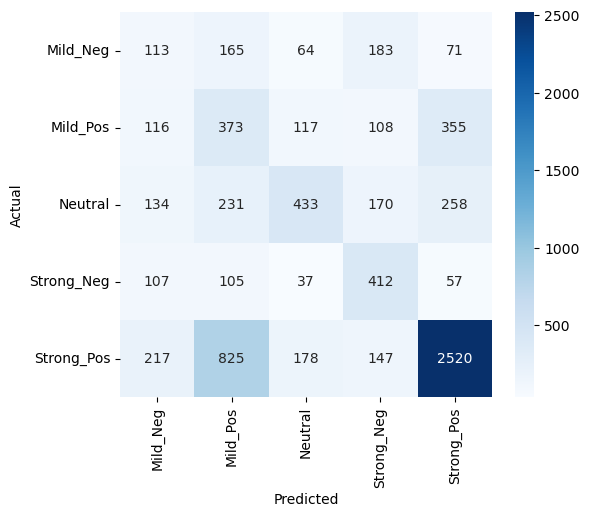

In [45]:
label_names = ['Mild_Neg', 'Mild_Pos', 'Neutral', 'Strong_Neg', 'Strong_Pos'] 
# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

- There is confusion between Mild_Pos and Strong_Pos — many Mild_Pos tweets are classified as Strong_Pos.
- Similarly, Neutral and Mild_Pos are often confused, which might reflect overlapping language features.
- The model is fairly good at predicting Strong_Pos correctly (2237 correct), but tends to misclassify Mild_Pos heavily (916 predicted as Strong_Pos).
- This suggests the model might be biased towards more extreme classes or struggles with subtle sentiments.

In [46]:
# F1 Scores for each class
f1_scores = f1_score(all_labels, all_preds, average=None)
for i, label in enumerate(label_names):
    print(f"F1 Score for {label}: {f1_scores[i]:.4f}")

# Overall Accuracy
accuracy = accuracy_score(all_labels, all_preds)
print(f"\nAccuracy: {accuracy:.4f}")

F1 Score for Mild_Neg: 0.1761
F1 Score for Mild_Pos: 0.2695
F1 Score for Neutral: 0.4214
F1 Score for Strong_Neg: 0.4741
F1 Score for Strong_Pos: 0.7051

Accuracy: 0.5137


- Strong_Pos and Strong_Neg have relatively high F1 scores (>0.54), meaning the model detects strong sentiments better.
- Mild sentiments and Neutral are harder to predict (F1 scores around 0.3–0.4), indicating the model struggling here.

In [47]:
# 4. Multi-class AUC (One-vs-Rest)
# Convert labels to LongTensor and one-hot encode
y_true_tensor = torch.tensor(all_labels).long()
y_true_onehot = F.one_hot(y_true_tensor, num_classes=len(label_names)).numpy()

# Calculate AUC for each class
auc_scores = []
for i in range(len(label_names)):
    auc_score = roc_auc_score(y_true_onehot[:, i], all_probs[:, i])
    auc_scores.append(auc_score)
    print(f"AUC for {label_names[i]}: {auc_score:.4f}")


AUC for Mild_Neg: 0.7496
AUC for Mild_Pos: 0.6175
AUC for Neutral: 0.7027
AUC for Strong_Neg: 0.8533
AUC for Strong_Pos: 0.8022


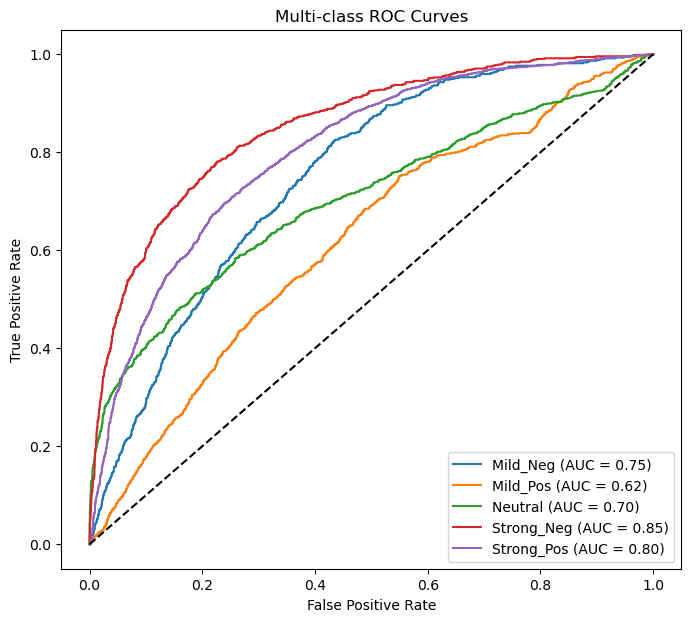

In [48]:
# Plot ROC curve for each class
plt.figure(figsize=(8,7))
for i in range(len(label_names)):
    fpr, tpr, _ = roc_curve(y_true_onehot[:, i], all_probs[:, i])
    plt.plot(fpr, tpr, label=f"{label_names[i]} (AUC = {auc_scores[i]:.2f})")

plt.plot([0, 1], [0, 1], "k--")  # diagonal
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-class ROC Curves")
plt.legend(loc="lower right")
plt.show()